In [7]:
import argparse
import os
import re
import fnmatch
from typing import Dict, List, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pickle

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 24
plt.rcParams['axes.labelsize'] = 48
plt.rcParams['axes.titlesize'] = 48
plt.rcParams['xtick.labelsize'] = 24
plt.rcParams['ytick.labelsize'] = 24
plt.rcParams['legend.fontsize'] = 18

In [8]:
actions = [
    "cartesian_position",
    "joint_position",
    "joint_velocity"
] 

In [9]:
use_prop = True

In [10]:
folder_path = "/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/"

In [11]:
action = actions[0]

In [12]:
file_paths = [
    os.path.join(folder_path, f"{action}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
    for i in range(10)
]
print(file_paths)

['/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_0.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_1.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_2.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_3.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_4.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_5.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_6.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_7.pkl.csv',

In [13]:
df = pd.read_csv(f"{folder_path}/cartesian_position_use_prop_False_trial_0_success.pkl.csv")
df

FileNotFoundError: [Errno 2] No such file or directory: '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs//cartesian_position_use_prop_False_trial_0_success.pkl.csv'

In [14]:
dfs = []
for path in file_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        # Extract trial number from filename using regex
        match = re.search(r"trial_(\d+)", os.path.basename(path))
        trial = int(match.group(1)) if match else None
        df['trial'] = trial
        dfs.append(df)

all_results = pd.concat(dfs, ignore_index=True)
all_results

ValueError: No objects to concatenate

In [10]:
all_results.groupby('trial')['success'].any().mean() * 100

np.float64(70.0)

In [11]:
trial_stats = all_results.groupby('trial').agg(
    num_collisions=('has_collided', 'sum'),
    trial_length=('has_collided', 'count')
)
trial_stats['trial_collision_rate'] = trial_stats['num_collisions'] / trial_stats['trial_length']
trial_stats

,num_collisions,trial_length,trial_collision_rate
trial,,,
0,0,450,0.000000
1,0,500,0.000000
2,0,400,0.000000
3,0,1000,0.000000
4,53,550,0.096364
5,87,850,0.102353
6,0,450,0.000000
7,0,1350,0.000000
8,0,1500,0.000000


In [ ]:
results = {}
for act in actions:
    file_paths = [
        os.path.join(folder_path, f"{act}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
        for i in range(10)
    ]
    dfs = []
    for path in file_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            match = re.search(r"trial_(\d+)", os.path.basename(path))
            trial = int(match.group(1)) if match else None
            df['trial'] = trial
            dfs.append(df)
    if dfs:
        all_results = pd.concat(dfs, ignore_index=True)
        success_rate = all_results.groupby('trial')['success'].any().mean() * 100
        
        results[act] = success_rate
    else:
        results[act] = None
# Show bar plot of success rates for each action
results_df = pd.DataFrame(list(results.items()), columns=['action', 'success_rate'])
results_df.to_csv('success_rates_by_action.csv', index=False)

: 

<Figure size 800x600 with 0 Axes>

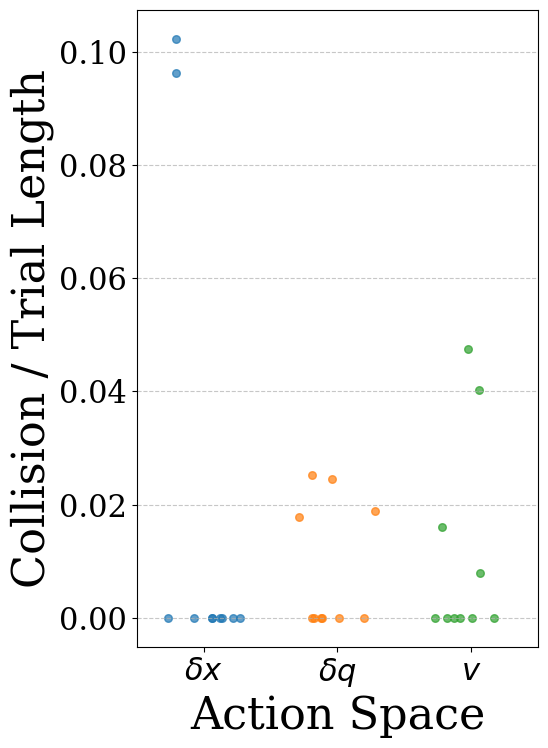

In [19]:
plt.figure(figsize=(8, 6))
collision_rates = []
labels = []
for act in actions:
    file_paths = [
        os.path.join(folder_path, f"{act}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
        for i in range(10)
    ]
    dfs = []
    for path in file_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            match = re.search(r"trial_(\d+)", os.path.basename(path))
            trial = int(match.group(1)) if match else None
            df['trial'] = trial
            dfs.append(df)
    if dfs:
        all_results = pd.concat(dfs, ignore_index=True)
        trial_stats = all_results.groupby('trial').agg(
            num_collisions=('has_collided', 'sum'),
            trial_length=('has_collided', 'count')
        )
        trial_stats['trial_collision_rate'] = (trial_stats['num_collisions'] / trial_stats['trial_length'])
        collision_rates.append(trial_stats['trial_collision_rate'].dropna())
        labels.append(act)
labels = [r"$\delta x$", r"$\delta q$", r"$v$"]
plt.figure(figsize=(6, 8))
np.random.seed(42)  # For reproducibility
for i, rates in enumerate(collision_rates):
    y = rates.values
    # Add a small random jitter to x to avoid overlap
    x = np.full_like(y, i, dtype=float) + np.random.uniform(-0.3, 0.3, size=len(y))
    plt.scatter(x, y, alpha=0.7, s=30, label=labels[i])
plt.xticks(range(len(labels)), labels, fontsize=22)
plt.ylabel('Collision / Trial Length', fontsize=32)
plt.xlabel('Action Space', fontsize=32)
# plt.title('Average Collision Rate Across Trials', fontsize=20)
plt.yticks(fontsize=22)
plt.xlim(-0.5, len(labels)-0.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"collision_rate_prop_{use_prop}_dotplot.pdf")
plt.show()



In [14]:
average_jerks = []
for jerks in joint_jerks_data:
    avg = jerks.mean()
    average_jerks.append(avg)

for label, avg in zip(labels, average_jerks):
    print(f"Average joint jerk for {label}: {avg:.3f}")

NameError: name 'joint_jerks_data' is not defined

<Figure size 800x600 with 0 Axes>

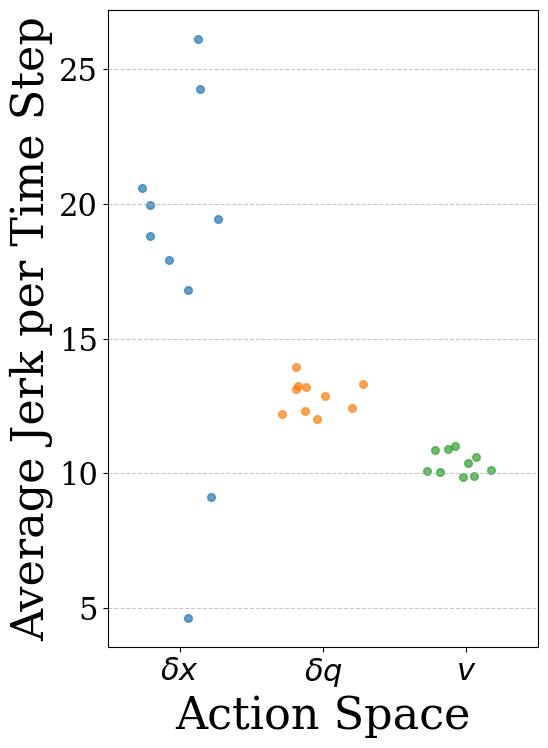

In [17]:
plt.figure(figsize=(8, 6))
collision_rates = []
labels = []
for act in actions:
    file_paths = [
        os.path.join(folder_path, f"{act}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
        for i in range(10)
    ]
    dfs = []
    for path in file_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            match = re.search(r"trial_(\d+)", os.path.basename(path))
            trial = int(match.group(1)) if match else None
            df['trial'] = trial
            dfs.append(df)
    if dfs:
        all_results = pd.concat(dfs, ignore_index=True)
        trial_stats = all_results.groupby('trial').agg(
            jerks=('joint_jerks', 'mean')
        )
        collision_rates.append(trial_stats['jerks'].dropna())
        labels.append(act)
# To use LaTeX in matplotlib labels, wrap your label strings with r"$...$"
labels = [r"$\delta x$", r"$\delta q$", r"$v$"]
plt.figure(figsize=(6, 8))
np.random.seed(42)  # For reproducibility
for i, rates in enumerate(collision_rates):
    y = rates.values
    # Add a small random jitter to x to avoid overlap
    x = np.full_like(y, i, dtype=float) + np.random.uniform(-0.3, 0.3, size=len(y))
    plt.scatter(x, y, alpha=0.7, s=30, label=labels[i])
plt.xticks(range(len(labels)), labels, fontsize=22)
plt.ylabel('Average Jerk per Time Step', fontsize=32)
plt.xlabel('Action Space', fontsize=32)
# plt.title('Average Collision Rate Across Trials', fontsize=20)
plt.yticks(fontsize=22)
plt.xlim(-0.5, len(labels)-0.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"jerk_prop_{use_prop}_dotplot.pdf")
plt.show()